In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'Data/02_Prepared_Data/cleaned_cyclistic_data.csv')

In [7]:
# To keep days of the week in chronological order instead of alphabetical
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

# To keep months in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

In [2]:
# Set a professional visual theme for our charts
sns.set_theme(style="whitegrid")
# Set a custom color palette (e.g., Blue for Members, Orange for Casuals)
custom_palette = {'member': '#1f77b4', 'casual': '#ff7f0e'}

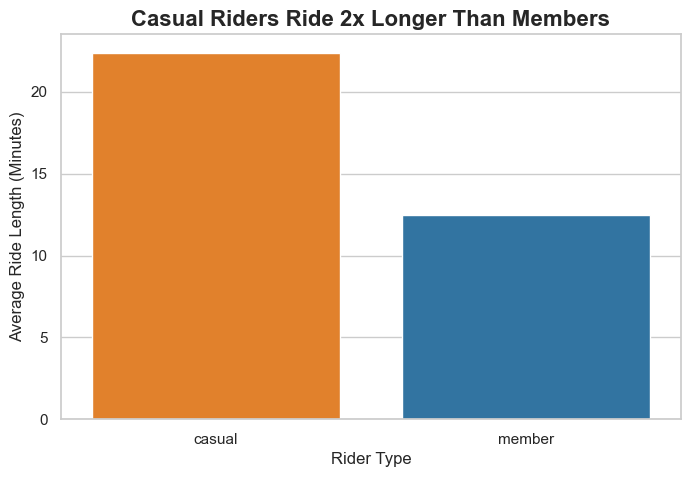

In [5]:
# Chart 1 : The Duration Difference

# 1. Group the data
avg_duration = df.groupby('member_casual', as_index=False)['ride_length'].mean()

# 2. Create the plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=avg_duration, 
    x='member_casual', 
    y='ride_length', 
    hue='member_casual', 
    palette=custom_palette, 
    legend=False)

# 3. Add executive-friendly titles and labels
plt.title('Casual Riders Ride 2x Longer Than Members', fontsize=16, fontweight='bold')
plt.xlabel('Rider Type', fontsize=12)
plt.ylabel('Average Ride Length (Minutes)', fontsize=12)

# 4. Save the chart to your folder
plt.savefig('Data/02_Prepared_Data/chart1_avg_duration.png', bbox_inches='tight')
plt.show()

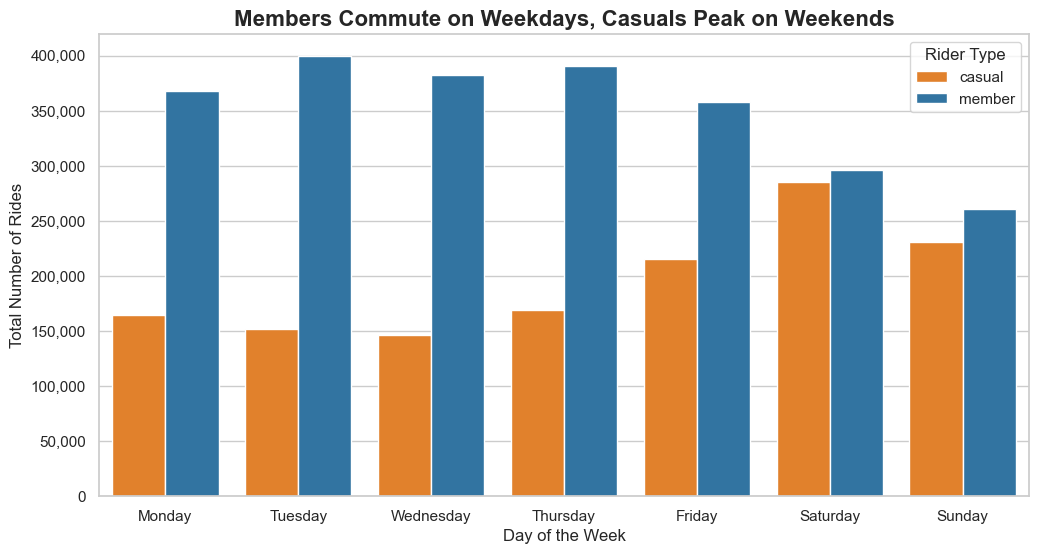

In [10]:
# Chart 2 - The Commuter vs. Weekend Warrior

# 1. Group the data
rides_by_day = df.groupby(['day_of_week', 'member_casual'], observed=False, as_index=False).size()

# 2. Create the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=rides_by_day, x='day_of_week', y='size', hue='member_casual', palette=custom_palette)

# 3. Add executive-friendly titles and labels
plt.title('Members Commute on Weekdays, Casuals Peak on Weekends', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Number of Rides', fontsize=12)
plt.legend(title='Rider Type')

# format y-axis to show millions cleanly
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 4. Save the chart
plt.savefig('Data/02_Prepared_Data/chart2_rides_by_day.png', bbox_inches='tight')
plt.show()

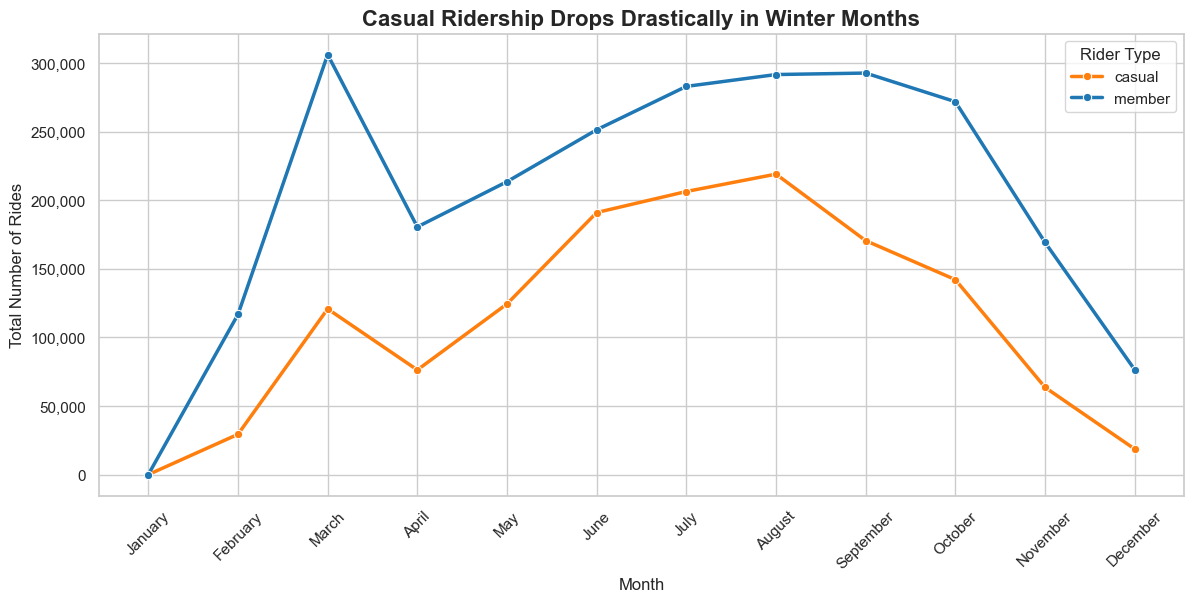

In [13]:
# Chart 3 - Seasonality

# 1. Group the data
rides_by_month = df.groupby(['month', 'member_casual'], observed=False, as_index=False).size()

# 2. Create the plot
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=rides_by_month, x='month', y='size', hue='member_casual', 
                  palette=custom_palette, marker='o', linewidth=2.5)

# 3. Add executive-friendly titles and labels
plt.title('Casual Ridership Drops Drastically in Winter Months', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Number of Rides', fontsize=12)
plt.xticks(rotation=45) # Rotate month names so they don't overlap
plt.legend(title='Rider Type')

# format y-axis to show millions cleanly
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 4. Save the chart
plt.savefig('Data/02_Prepared_Data/chart3_seasonality.png', bbox_inches='tight')
plt.show()